These cells connect the notebook with your google drive.

You **must** run this cell and allow access.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Plotting data with matplotlib

<section class="objectives panel panel-warning">
<div class="panel-heading">
<h2><span class="fa fa-certificate"></span>Learning Objectives</h2>
</div>
</section>

> * How to plot basic x, y data in Python
> * How to display images
> * How to label axes
> * Save plots to many formats, including PNG and PDF
> * More complex plots: histograms, 3D plotting, subplots
> * String formatting

The key to understanding data is to visualise it. The clear presentation of your data is one of the most important tasks for scientists. On a personal level, the horrible plotting options in Excel is one of the reasons a little part of me dies every time a student does their data analysis in a spreadsheet.

There are many Python plotting libraries for display of data but [Matplotlib](http://matplotlib.org/) is the de-facto standard. In this session we'll learn how to display our data using matplotlib.

Matplotlib is imported like so:

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

If you are using a Python shell, or writing a Python program file (.py), you only need the line that says ```import matplotlib.pyplot as plt```.

However, if you are running in the Jupyter notebook, and want your plots to display inside the notebook you also need to run the ```%matplotlib inline``` command. This needs to be run **before** importing matplotlib.

## Basic X-Y plots

To get started, let's generate some fake data using numpy - here I'm plotting $y = \sin x$ between 0 and $4\pi$.

In [3]:
import numpy as np
x = np.linspace(0.0, 4.0*np.pi, 100) #evenly spaced grid of 100 points
y = np.sin(x)

The matplotlib command [plot](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot) is used to plot simple x-y data. Let's read the help for this function.

In [ ]:
plt.plot?

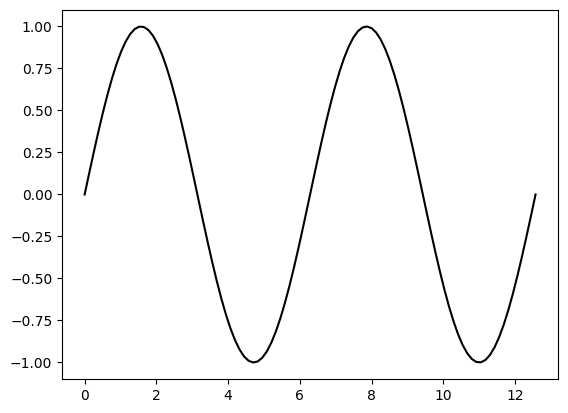

In [4]:
plt.plot(x, y, 'k-')
plt.show()

Notice how we used ```plt.show()``` to display the figure we'd created.

I hope we can agree that the plot above is crap. As a bare minimum it needs x-y axis labels. I also feel like a more colorful line:

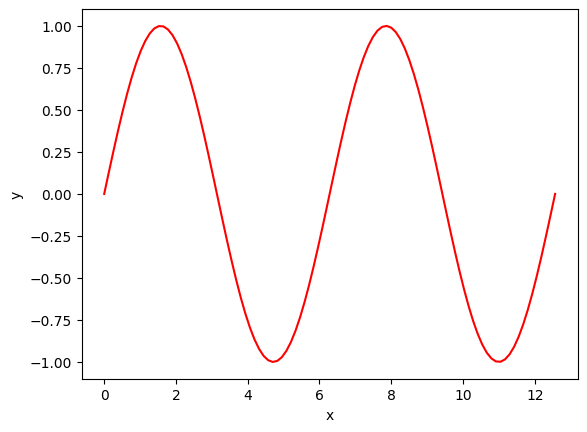

In [5]:
plt.plot(x, y, 'r-')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## More control - figures and axes

When we called the ```plt.plot``` function, it created a figure and a set of axes for us automatically. Quite often in matplotlib, we want to create figure and axis *objects* by hand, and use the axis object to do the plotting. The real advantage of this approach becomes obvious when a figure contains more than one subplot.

The ```plt.subplots``` function will create a figure and axis object for us:

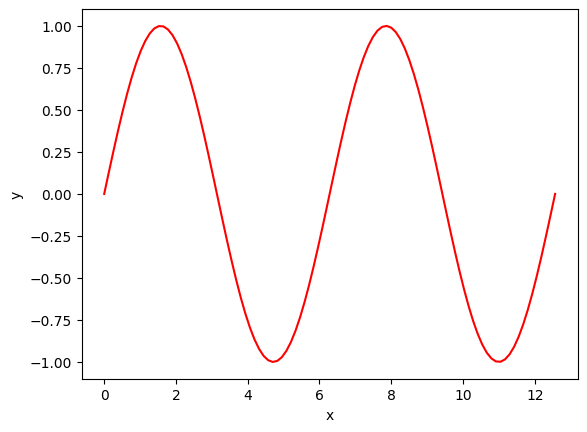

In [7]:
# create variables to store the figure and axis objects
fig, axis = plt.subplots()

# use axis object for plotting
axis.plot(x, y, 'r-')
axis.set_ylabel('y') # notice the slightly different style for labels
axis.set_xlabel('x')

plt.show()

## Subplots

Although a little more code is involved, one advantage is that it is easy to add multiple subplots - just provide the ```plt.subplots``` function with the number of rows and columns:

Plotting on subplot: i= 0  j= 0
Plotting on subplot: i= 0  j= 1
Plotting on subplot: i= 1  j= 0
Plotting on subplot: i= 1  j= 1


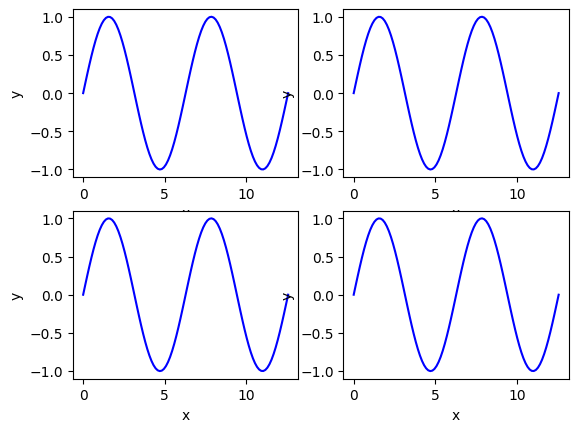

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2)
# axes is a 2x2 list of axis objects

for i in range(2):
    for j in range(2):
        print("Plotting on subplot: i=", i, " j=", j)
        axis = axes[i, j]

        axis.plot(x, y, 'b-')
        axis.set_xlabel('x')
        axis.set_ylabel('y')

plt.show()

This is nice, but the overlapping labels are an issue. The ```fig``` object has a function called ```tight_layout``` that will fix that for us:

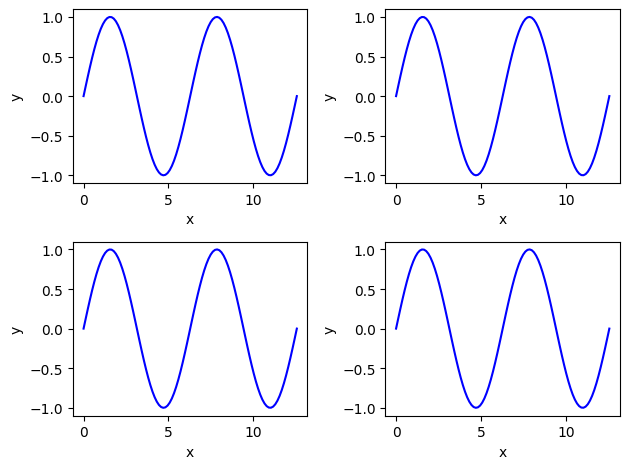

In [9]:
fig, axes = plt.subplots(nrows=2,ncols=2)

for i in range(2):
    for j in range(2):
        axis = axes[i, j]

        axis.plot(x, y, 'b-')
        axis.set_xlabel('x')
        axis.set_ylabel('y')

fig.tight_layout()
plt.show()

## Multiple lines and legends

What if I want to plot several lines on the same figure? You can just make multiple calls to the ```plot``` function. The ```plot``` function also has an optional ```label``` argument that helps us label each line:

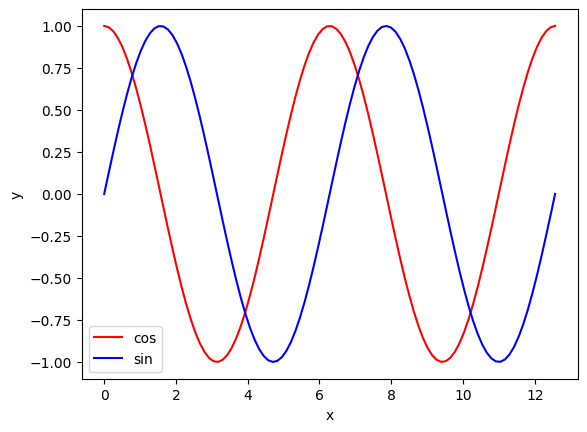

In [10]:
x = np.linspace(0, 4.0*np.pi, 100)

fig, axis = plt.subplots()
axis.plot(x, np.cos(x), 'r-', label='cos')
axis.plot(x, np.sin(x), 'b-', label='sin')

axis.set_xlabel('x')
axis.set_ylabel('y')

axis.legend() # draw a legend on figure

plt.show()

## Limits

The graph above is OK, but I'm unhappy with the limits. You can set the x and y limits with ```set_xlim``` and ```set_ylim```:

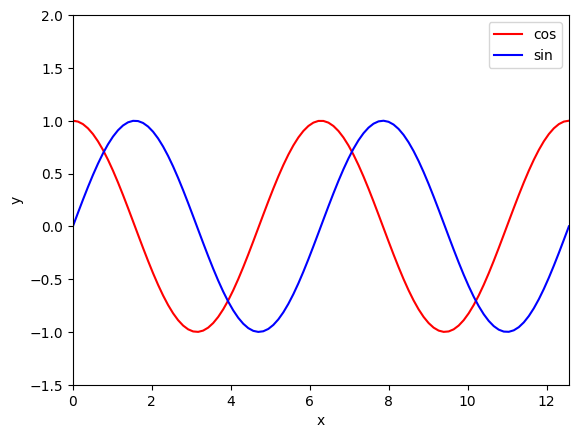

In [11]:
x = np.linspace(0, 4.0*np.pi, 100)

fig, axis = plt.subplots()
axis.plot(x, np.cos(x), 'r-', label='cos')
axis.plot(x, np.sin(x), 'b-', label='sin')

axis.set_xlabel('x')
axis.set_ylabel('y')

axis.legend() # draw a legend on figure

axis.set_ylim(-1.5, 2.0)
axis.set_xlim(0.0, 4.0*np.pi)

plt.show()

Much nicer!

<section class="challenge panel panel-success">
<div class="panel-heading">
<h2><span class="fa fa-pencil"></span>Simple X-Y plots</h2>
</div>
</section>

> On *one figure*, plot $y = \sin x$, $y = \cos x$ and $y = \tan x$ between $-\pi/2 < x < \pi/2$. Plot $\tan x$ with a dotted line, add a legend, and make sure that the limits are set sensibly.

In [ ]:
# insert your code here

## Figure size and saving figures

We can set the figure size by passing an argument to the ```subplots``` function. The ```figsize``` argument is the width and height of the figure in inches. We can also set the DPI (dots-per-inch) of the figure the same way:

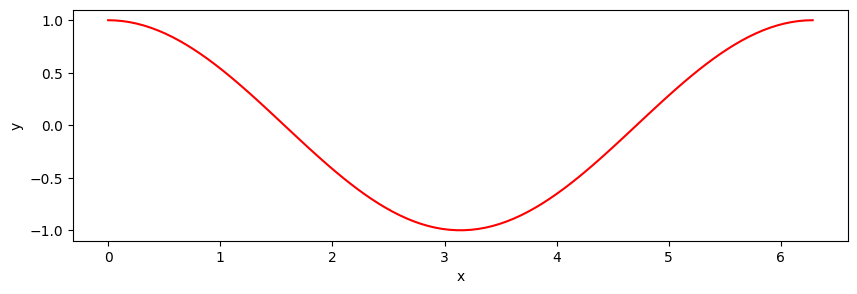

In [12]:
fig, axis = plt.subplots(figsize=(10, 3), dpi=100)

x = np.linspace(0.0, 2*np.pi, 100)
axis.plot(x, np.cos(x), 'r-')
axis.set_xlabel('x')
axis.set_ylabel('y')
plt.show()

### Saving figures

To save a figure to a file we can use the ```savefig``` method in the ```fig``` object:

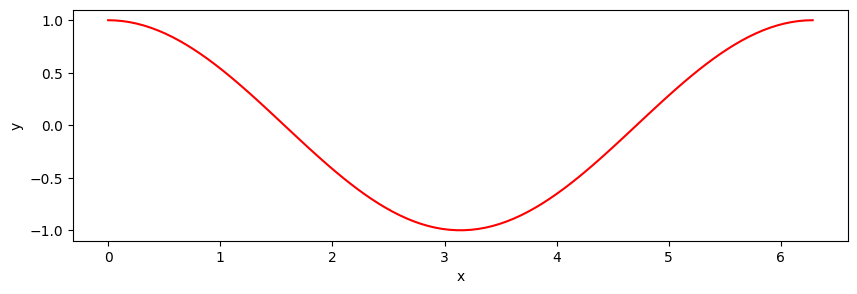

In [14]:
fig, axis = plt.subplots(figsize=(10,3), dpi=100)

x = np.linspace(0.0, 2*np.pi, 100)
axis.plot(x, np.cos(x), 'r-')
axis.set_xlabel('x')
axis.set_ylabel('y')
fig.savefig('filename.png')

In [19]:
ls

drive/  filename.png  sample_data/


A couple of things to note: many file formats are supported, notably PNG, JPG, PDF and SVG. You must call ```savefig``` **before** calling ```plt.show``` - the latter "empties" the figure object, so calling ```savefig``` afterwards will not do anything.

> #### Saving figures with google colab

> Google colab is running on a **virtual** computer, which is destroyed when you close the notebook. The code above saves the file to the virtual computer, and it's impossible for us to use it later. You can get round this by saving to your Google drive, e.g

> ```python
> fig.savefig('/content/drive/MyDrive/filename.png')
> ```

## Formatting lines, labels, axes

The plots shown so far are fine, but quite often we want to be able change the font sizes, line colors, line widths, line styles, etc. Matplotlib provides literally endless opportunities for plot formatting. Rather than go into them all here, I have provided a reference notebook (`01a_plotformatting.ipynb`) which you can use as a guide to make neatly formatted plots for publication.

---

## Other 2D plots

The ```plot``` method is fine for x, y line plots, but there are a number of other functions for making different kinds of plots. For a gallery of all the types of plots, you can look at the [matplotlib gallery](http://matplotlib.org/gallery.html) - each figure in the gallery shows the code used to produce it. Some of the more useful examples are shown below.

### Histograms

The example below generates 100,000 Gaussian random numbers, and plots the histogram and a normalised histogram, whose total area adds up to 1.

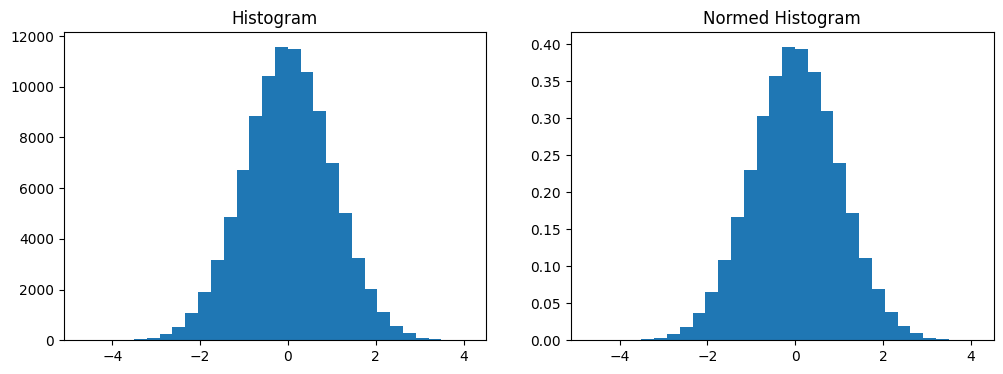

In [20]:
nums = np.random.normal(loc=0,scale=1,size=100000)
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(12,4))

axes[0].hist(nums, bins=30)
axes[0].set_title('Histogram')

axes[1].hist(nums, bins=30, density=True)
axes[1].set_title('Normed Histogram')

plt.show()

### Errorbar plots

If we're going to plot real data we need to be able to plot x,y data with errorbars! In the cell below I'm going to load in some example data - the brightness vs. time of an exoplanet host, Wasp-12. The data file format looks like this

```
54835.817914435 1.0027e+00 1.5118e-03
54835.818901894 1.0046e+00 1.5249e-03
54835.819911092 1.0029e+00 1.4443e-03
54835.820920291 1.0016e+00 1.4374e-03
```

The three columns are time, flux and error.

In [21]:
# Look! Notice the use of unpack=True and list unpacking to get 3, separate 1D arrays
x, y, e = np.loadtxt('/content/drive/Shareddrives/ClassroomShared/PHY241/data/Session2/wasp12.txt', unpack=True)

Now I can use the ```errorbar``` function to plot this data. By default the ```errorbar``` command will join up the points with a line, note how I disable this line, and set the marker style using the `fmt` argument:

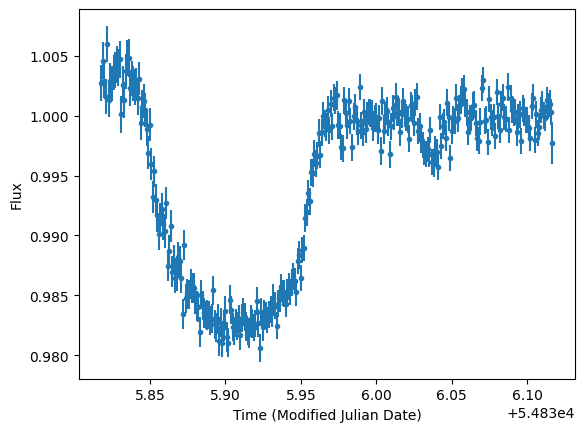

In [22]:
fig, axis = plt.subplots()

axis.errorbar(x, y, yerr=e, fmt='.')
axis.set_xlabel('Time (Modified Julian Date)')
axis.set_ylabel('Flux')

plt.show()

<section class="challenge panel panel-success">
<div class="panel-heading">
<h2><span class="fa fa-pencil"></span>Error bar plots</h2>
</div>
</section>

> Tidy up the error bar plot above:
* the x-axis data start at 54835.8179... Subtract off the integer part and adjust the x-axis label to reflect this
* Change the errorbar and marker color to red
* adjust the transparency (alpha) of the points to 0.8
* Change the y-axis label to "Normalised Flux"

> You might find it useful to look at the help for the errorbar function.

In [ ]:
# WRITE YOUR CODE HERE

### Scatter plots

The ```scatter``` function is useful for scatter plots, particularly ones where you want marker sizes and colours to differ:

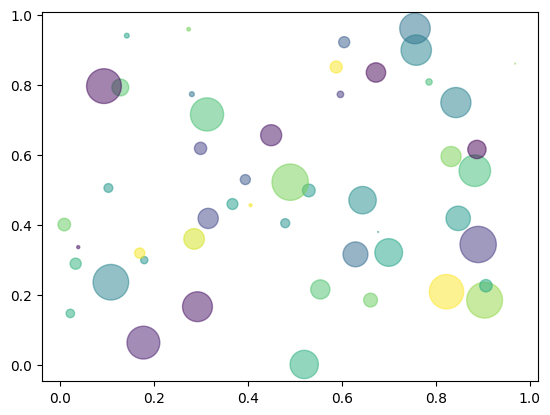

In [23]:
N = 50
x = np.random.uniform(size=N)
y = np.random.uniform(size=N)
colors = np.random.uniform(size=N)
area = np.pi * (15 * np.random.uniform(size=N))**2 # 0 to 15 point radiuses

plt.scatter(x, y, s=area, c=colors, alpha=0.5)
plt.show()

## Image plots

One thing that astronomers do a lot of is plotting images! Matplotlib has excellent support for plotting images. Here I will use the ```astropy``` library to load a FITS image of the Pleiades (there'll be more on reading FITS images in a later session).

In [24]:
import astropy.io.fits as fits
image = fits.getdata('/content/drive/Shareddrives/ClassroomShared/PHY241/data/Session2/pleiades.fits')

# image is just a numpy array
print (image.mean())
print (image.std())
print (image.shape)

0.004578544
0.0012347769
(875, 875)


We can see the image is 875x875 pixels. We can use the ```imshow``` command to plot this image:

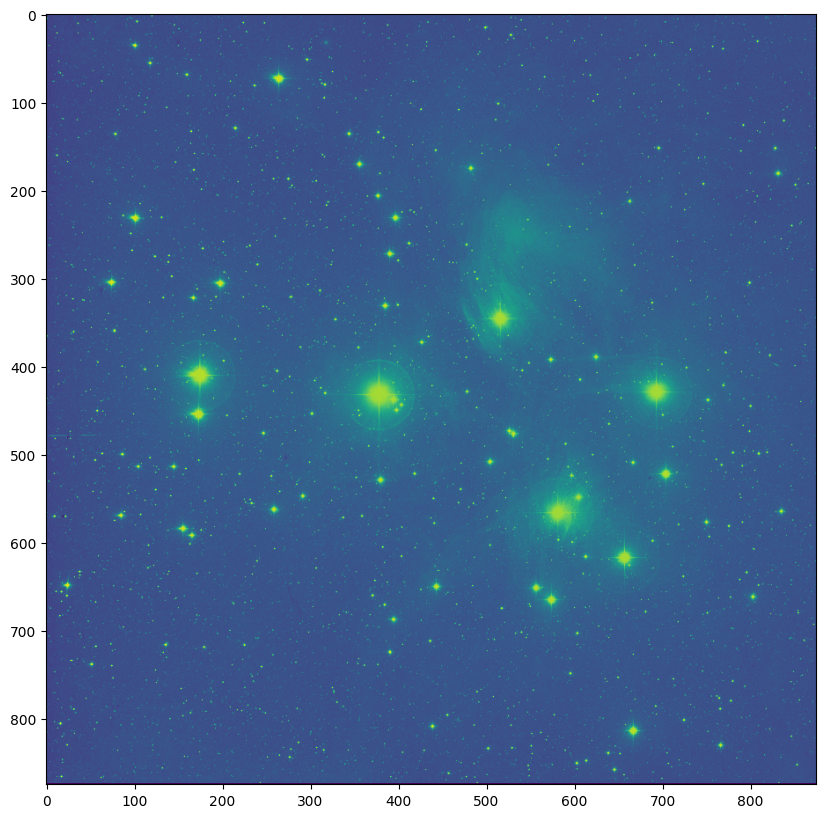

In [25]:
fig, axis = plt.subplots(figsize=(10,10))
axis.imshow(image)
plt.show()

This is not great. The [colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html) looks like an unusual choice for stars, and the image doesn't seem to be the right way up.

The reason for the image orientation is that it is a convention in computer graphics for the [0,0] element of the array in the upper left. We would normally think of the [0,0] array element being bottom left.

We'll go into more detail about plotting images in the session on image handling, but for now let's change the colormap to be a greyscale, and fix the location of the origin.

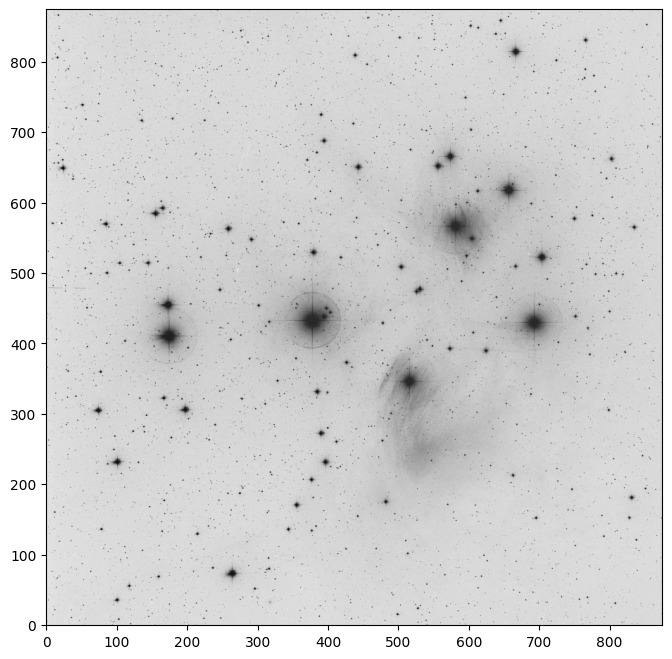

In [27]:
fig, axis = plt.subplots(figsize=(8, 8))
implot = axis.imshow(image, cmap=plt.get_cmap('Greys'), origin='lower')
axis.grid(False)
plt.show()

## 3d Plots

We won't go into 3D plotting in much detail. but it's worth pointing out that 3D axes can be created by creating a figure and calling the ```add_subplot``` function with the ```projection='3d'``` argument:

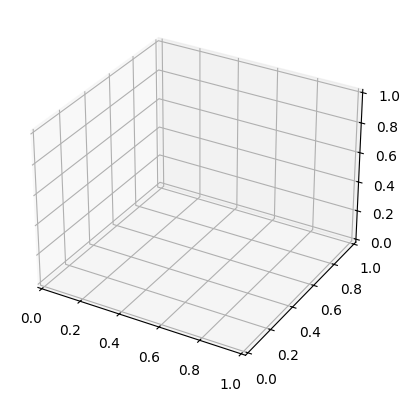

In [28]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
axis = fig.add_subplot(projection='3d')

As a quick example, I've made a 3D scatter plot of some random points below. For more information on 3D plotting in matplotlib, see the tutorial [here](https://beta.oreilly.com/learning/three-dimensional-plotting-in-matplotlib).

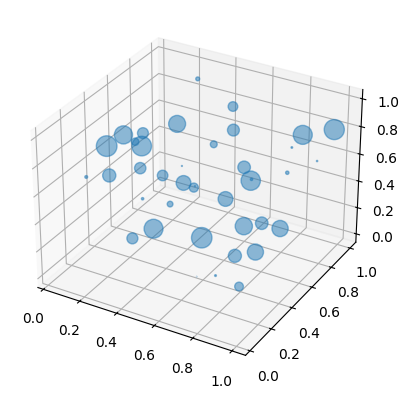

In [30]:
N = 40
x = np.random.uniform(size=N)
y = np.random.uniform(size=N)
z = np.random.uniform(size=N)
area =  15 * np.random.uniform(size=N)

fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter(x,y,z,s=area**2,alpha=0.5)
plt.show()

---
## Printing out formatted text

As well as plotting graphs, printing out nicely formatted text can be important for presenting your results. We can display nicely formatted text using **f-strings**:

In [32]:
x = 100.1010101
a_string = f"The value of x is {x}"
print (a_string)

The value of x is 100.1010101


F-strings work by replacing any curly brackets within the string by the arguments it is given. You can use as many curly brackets as you like:

In [33]:
x = np.random.normal(loc=10, scale=1, size=100000)
a_string = f"The mean of x is {x.mean()}, the standard deviation is {x.std()}"
print (a_string)

The mean of x is 10.001504387124315, the standard deviation is 1.0041255161679545


What if we want to change the number of decimal places? Python has a number of *string formatting codes* that allow us to specify how we want the string to look. For example, decimal numbers are formatted with a code like ```:.2f``` which means "print out a floating point number with 2 decimal places:

In [34]:
x = np.random.normal(loc=10, scale=1, size=100000)
a_string = f"The mean of x is {x.mean():.2f}, the standard deviation is {x.std():.2f}"
print (a_string)

The mean of x is 10.00, the standard deviation is 1.00


Rather than produce a complete view of string formatting I'll refer you to this [nice online guide](https://realpython.com/python-string-formatting/).